In [17]:
DATA_DIR       = Path("f1_data")
RAW_DIR        = DATA_DIR / "raw"
RANKINGS_DIR   = DATA_DIR / "rankings"
MATRICES_DIR   = DATA_DIR / "matrices"
PER_SEASON_DIR = MATRICES_DIR / "per_season"


In [ ]:
"""
Formula 1 Race Results → Strict Complete Rankings
---------------------------------------------------
Downloads F1 race finishing positions from the Jolpica API
(api.jolpi.ca — the open-source successor to the Ergast API)
and converts each race into a strict complete ranking of drivers.

Each race naturally produces one strict complete ranking:
    assessor  = one race
    items     = drivers
    rank      = finishing position (1 = winner)

This is exactly the data format needed for Mallows mixture models.
DNFs (did-not-finish) are handled explicitly — see options below.

Dependencies: pip install requests pandas numpy

Output folder structure:
    f1_data/
        raw/            ← raw API results
        rankings/       ← long-format rankings
        matrices/       ← rank matrices (all seasons)
            per_season/ ← one matrix per season
"""

import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests

# ──────────────────────────────────────────────
# Output directories
# ──────────────────────────────────────────────




# ──────────────────────────────────────────────
# 1.  Jolpica API helpers
# ──────────────────────────────────────────────

BASE_URL = "https://api.jolpi.ca/ergast/f1"
PAUSE    = 1.0   # seconds between requests — be a polite API user


def _get(url: str, params: dict | None = None, max_retries: int = 5) -> dict:
    """GET with exponential backoff on 429 Too Many Requests."""
    for attempt in range(max_retries):
        resp = requests.get(url, params=params, timeout=30)
        if resp.status_code == 429:
            wait = 2 ** attempt  # 1, 2, 4, 8, 16 seconds
            print(f"\n  Rate limited (429). Waiting {wait}s before retry {attempt + 1}/{max_retries}...")
            time.sleep(wait)
            continue
        resp.raise_for_status()
        time.sleep(PAUSE)
        return resp.json()
    raise requests.HTTPError(f"Still getting 429 after {max_retries} retries: {url}")


def get_race_results(season: int, round_: int) -> list[dict]:
    """
    Fetch finishing results for one race.
    Returns a list of result dicts from the Jolpica API.
    """
    url  = f"{BASE_URL}/{season}/{round_}/results.json"
    data = _get(url, params={"limit": 30})
    races = data["MRData"]["RaceTable"]["Races"]
    if not races:
        return []
    return races[0]["Results"]


def get_season_schedule(season: int) -> list[dict]:
    """Return the list of races (with round numbers) for a season."""
    url  = f"{BASE_URL}/{season}.json"
    data = _get(url, params={"limit": 30})
    return data["MRData"]["RaceTable"]["Races"]


# ──────────────────────────────────────────────
# 2.  Download one full season
# ──────────────────────────────────────────────

def download_season(season: int) -> pd.DataFrame:
    """
    Download all race results for a season and return a flat DataFrame.

    Columns:
        season, round, race_name, date, circuit,
        driver_id, driver_code, driver_name,
        constructor, grid_position, finish_position,
        points, status, laps
    """
    schedule = get_season_schedule(season)
    n_rounds = len(schedule)
    rows = []

    for race in schedule:
        rnd       = int(race["round"])
        race_name = race["raceName"]
        date      = race.get("date", "")
        circuit   = race["Circuit"]["circuitName"]

        print(f"  {season} Round {rnd:2d}/{n_rounds}  {race_name}...", end=" ")
        results = get_race_results(season, rnd)

        if not results:
            print("no data")
            continue

        for r in results:
            driver = r["Driver"]
            rows.append({
                "season":          season,
                "round":           rnd,
                "race_name":       race_name,
                "date":            date,
                "circuit":         circuit,
                "driver_id":       driver["driverId"],
                "driver_code":     driver.get("code", ""),
                "driver_name":     f"{driver['givenName']} {driver['familyName']}",
                "constructor":     r["Constructor"]["name"],
                "grid_position":   int(r.get("grid", 0)),
                "finish_position": int(r["position"]) if r["positionText"].isdigit() else None,
                "points":          float(r.get("points", 0)),
                "status":          r.get("status", ""),
                "laps":            int(r.get("laps", 0)),
            })

        n_classified = sum(1 for r in results if r["positionText"].isdigit())
        print(f"{n_classified} classified")

    return pd.DataFrame(rows)


def download_multiple_seasons(
    start: int = 1950,
    end:   int = 2023,
) -> pd.DataFrame:
    """Download and concatenate results for a range of seasons."""
    frames = []
    for season in range(start, end + 1):
        print(f"\n── Season {season} ──────────────────────────")
        df = download_season(season)
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


# ──────────────────────────────────────────────
# 3.  Convert to strict rankings
# ──────────────────────────────────────────────

def races_to_rankings(
    results: pd.DataFrame,
    dnf_strategy: str = "last",
    min_drivers:  int = 10,
) -> pd.DataFrame:
    """
    Convert raw race results to a strict ranking per race.

    Parameters
    ----------
    results      : raw DataFrame from download_season / download_multiple_seasons
    dnf_strategy : how to handle DNFs (Did Not Finish):
        'drop'    — exclude DNF drivers entirely; race may have fewer items
        'last'    — assign DNFs the lowest ranks (after finishers),
                    ordered by laps completed (more laps = better rank)
        'exclude' — exclude any race containing a DNF entirely
    min_drivers  : minimum classified drivers for a race to be kept

    Returns
    -------
    DataFrame with columns [season, round, race_name, date, circuit,
                             driver_id, driver_code, driver_name, rank]
    One row per driver per race, rank = 1 (winner) to N.
    """
    if dnf_strategy not in ("drop", "last", "exclude"):
        raise ValueError("dnf_strategy must be 'drop', 'last', or 'exclude'")

    records = []

    for (season, rnd), grp in results.groupby(["season", "round"]):
        meta = grp.iloc[0]

        finishers = grp[grp["finish_position"].notna()].copy()
        dnfs      = grp[grp["finish_position"].isna()].copy()

        if dnf_strategy == "exclude" and len(dnfs) > 0:
            continue  # skip any race with a DNF

        if dnf_strategy == "drop":
            ranked = finishers.sort_values("finish_position")
            ranked["rank"] = np.arange(1, len(ranked) + 1)

        else:  # 'last' — finishers first, then DNFs ordered by laps
            finishers = finishers.sort_values("finish_position")
            finishers["rank"] = np.arange(1, len(finishers) + 1)

            if len(dnfs) > 0:
                # More laps completed → ranked higher among DNFs
                dnfs = dnfs.sort_values("laps", ascending=False)
                dnfs["rank"] = np.arange(
                    len(finishers) + 1,
                    len(finishers) + len(dnfs) + 1
                )
                ranked = pd.concat([finishers, dnfs])
            else:
                ranked = finishers

        if len(ranked) < min_drivers:
            continue

        for _, row in ranked.iterrows():
            records.append({
                "season":      row["season"],
                "round":       row["round"],
                "race_name":   meta["race_name"],
                "date":        meta["date"],
                "circuit":     meta["circuit"],
                "driver_id":   row["driver_id"],
                "driver_code": row["driver_code"],
                "driver_name": row["driver_name"],
                "rank":        int(row["rank"]),
            })

    return pd.DataFrame(records).sort_values(["season", "round", "rank"]).reset_index(drop=True)


# ──────────────────────────────────────────────
# 4.  Build rank matrix for Mallows models
# ──────────────────────────────────────────────

def to_rank_matrix(
    rankings: pd.DataFrame,
    common_drivers_only: bool = True,
) -> tuple[np.ndarray, list[str], list[str]]:
    """
    Pivot to a matrix of shape (n_races × n_drivers).

    Entry [i, j] = rank of driver j in race i.

    Parameters
    ----------
    rankings             : output of races_to_rankings()
    common_drivers_only  : if True, keep only drivers who appear
                           in ALL races (guarantees complete matrix).
                           If False, missing values are filled with
                           the worst rank + 1 (absent = last).

    Returns
    -------
    matrix   : np.ndarray  shape (n_races, n_drivers)
    races    : list of "{season} R{round} {race_name}" labels
    drivers  : list of driver_id strings
    """
    rankings = rankings.copy()
    rankings["race_label"] = (
        rankings["season"].astype(str)
        + " R" + rankings["round"].astype(str).str.zfill(2)
        + " " + rankings["race_name"]
    )

    pivot = rankings.pivot_table(
        index="race_label",
        columns="driver_id",
        values="rank",
        aggfunc="first",
    )

    if common_drivers_only:
        present_in_all = pivot.notna().all(axis=0)
        n_dropped = (~present_in_all).sum()
        if n_dropped:
            print(f"  Dropping {n_dropped} drivers not in all races "
                  f"({present_in_all.sum()} remain).")
        pivot = pivot.loc[:, present_in_all]
    else:
        worst = pivot.max(axis=1)
        pivot = pivot.apply(lambda col: col.fillna(worst + 1))

    matrix  = pivot.values.astype(int)
    races   = list(pivot.index)
    drivers = list(pivot.columns)

    return matrix, races, drivers


# ──────────────────────────────────────────────
# 5.  Quick summary
# ──────────────────────────────────────────────

def summarise(results: pd.DataFrame, rankings: pd.DataFrame) -> None:
    print("\n── Raw Results ──────────────────────────────────")
    print(f"  Seasons : {results['season'].min()} – {results['season'].max()}")
    print(f"  Races   : {results.groupby(['season','round']).ngroups}")
    print(f"  Drivers : {results['driver_id'].nunique()}")
    dnf_pct = results["finish_position"].isna().mean() * 100
    print(f"  DNF rate: {dnf_pct:.1f}%")

    print("\n── Rankings ─────────────────────────────────────")
    n_races = rankings.groupby(["season", "round"]).ngroups
    print(f"  Races kept  : {n_races}")
    print(f"  Drivers/race: {rankings.groupby(['season','round'])['driver_id'].count().describe()[['min','mean','max']].round(1).to_dict()}")
    print("─────────────────────────────────────────────────\n")


# ──────────────────────────────────────────────
# 6.  Main — example usage
# ──────────────────────────────────────────────

if __name__ == "__main__":

    print("Downloading F1 race results from Jolpica API...")
    results = download_multiple_seasons(start=2010, end=2023)

    out = RAW_DIR / "f1_results_raw.csv"
    results.to_csv(out, index=False)
    print(f"\nSaved: {out}")

    rankings = races_to_rankings(results, dnf_strategy="last", min_drivers=15)
    summarise(results, rankings)

    example = rankings[(rankings["season"] == 2021) & (rankings["round"] == 1)]
    print("Example: 2021 Round 1 rankings")
    print(example[["rank", "driver_code", "driver_name"]].to_string(index=False))

    out = RANKINGS_DIR / "f1_rankings.csv"
    rankings.to_csv(out, index=False)
    print(f"\nSaved: {out}")

    print("\nBuilding rank matrix (common drivers across all races)...")
    matrix, races, drivers = to_rank_matrix(rankings, common_drivers_only=True)
    print(f"  Matrix shape: {matrix.shape}  (races × drivers)")

    out = MATRICES_DIR / "f1_rank_matrix.csv"
    pd.DataFrame(matrix, index=races, columns=drivers).to_csv(out)
    print(f"Saved: {out}")

    print("\nBuilding per-season rank matrices...")
    for season in sorted(rankings["season"].unique()):
        season_rankings = rankings[rankings["season"] == season]
        mat, race_labels, driver_ids = to_rank_matrix(season_rankings, common_drivers_only=True)
        print(f"  {season}: {mat.shape[0]} races × {mat.shape[1]} drivers")
        out = PER_SEASON_DIR / f"f1_rank_matrix_{season}.csv"
        pd.DataFrame(mat, index=race_labels, columns=driver_ids).to_csv(out)

    print(f"\nDone. All files saved under {DATA_DIR}/")
    print(
        f"\n  {RAW_DIR}/           ← raw API results\n"
        f"  {RANKINGS_DIR}/      ← long-format rankings\n"
        f"  {MATRICES_DIR}/      ← full rank matrix\n"
        f"  {PER_SEASON_DIR}/    ← per-season matrices"
    )



── Season 2010 ──────────────────────────
  2010 Round  1/19  Bahrain Grand Prix... 17 classified
  2010 Round  2/19  Australian Grand Prix... 14 classified
  2010 Round  3/19  Malaysian Grand Prix... 17 classified
  2010 Round  4/19  Chinese Grand Prix... 17 classified
  2010 Round  5/19  Spanish Grand Prix... 19 classified
  2010 Round  6/19  Monaco Grand Prix... 15 classified
  2010 Round  7/19  Turkish Grand Prix... 

KeyboardInterrupt: 

In [18]:
"""
Find a consistent driver subset → complete strict ranking matrix
----------------------------------------------------------------
Two ways to control the drivers-vs-races trade-off:

  min_race_frac  – keep drivers who raced in ≥ X% of all races
                   (lower → more drivers, fewer races)

  min_drivers    – keep AT LEAST this many drivers;
                   the algorithm finds the maximum races that fit.

Use explore_tradeoffs() first to see the full drivers/races table,
then call find_consistent_subset() with your chosen setting.
"""

import pandas as pd
import numpy as np


# ──────────────────────────────────────────────────────────────────────────────
# Helper: build presence matrix (reused by both functions below)
# ──────────────────────────────────────────────────────────────────────────────

def _presence_matrix(rankings: pd.DataFrame) -> pd.DataFrame:
    return (
        rankings.groupby(["season", "round", "driver_id"])
        .size()
        .unstack(fill_value=0)
        .astype(bool)
    )


def _prune_to_fixpoint(presence: pd.DataFrame, min_races: int, verbose: bool) -> pd.DataFrame:
    """Iteratively drop drivers < min_races and incomplete races until stable."""
    iteration = 0
    while True:
        iteration += 1
        counts       = presence.sum(axis=0)
        presence     = presence[counts[counts >= min_races].index]
        presence     = presence[presence.all(axis=1)]
        if verbose:
            print(f"  Iter {iteration}: {len(presence)} races × {len(presence.columns)} drivers"
                  f"  (threshold ≥ {min_races})")
        min_races = len(presence)          # tighten: now all remaining races required
        if (presence.sum(axis=0) >= min_races).all():
            break
    return presence


# ──────────────────────────────────────────────────────────────────────────────
# 1.  Explore the trade-off table
# ──────────────────────────────────────────────────────────────────────────────

def explore_tradeoffs(
    rankings: pd.DataFrame,
    fracs: list[float] | None = None,
) -> pd.DataFrame:
    """
    Print a table showing how many races and drivers you get for each
    min_race_frac threshold. Use this to pick a setting before calling
    find_consistent_subset().
    """
    if fracs is None:
        fracs = [round(f, 2) for f in np.arange(0.50, 1.01, 0.05)]

    presence_full = _presence_matrix(rankings)
    total_races   = len(presence_full)

    rows = []
    for frac in fracs:
        min_races = int(np.ceil(frac * total_races))
        pres      = _prune_to_fixpoint(presence_full.copy(), min_races, verbose=False)
        rows.append({
            "min_race_frac": frac,
            "min_races_threshold": min_races,
            "races_kept":   len(pres),
            "drivers_kept": len(pres.columns),
        })

    table = pd.DataFrame(rows)
    print(f"Total races available: {total_races}\n")
    print(table.to_string(index=False))
    return table


# ──────────────────────────────────────────────────────────────────────────────
# 2.  Find a consistent subset
# ──────────────────────────────────────────────────────────────────────────────

def find_consistent_subset(
    rankings: pd.DataFrame,
    min_race_frac: float | None = None,
    min_drivers:   int   | None = None,
    verbose: bool = True,
) -> tuple[pd.DataFrame, list[str]]:
    """
    Iteratively prune until every retained driver appears in every retained race.

    Provide exactly ONE of:
      min_race_frac  – keep drivers who appear in ≥ this fraction of races
      min_drivers    – binary-search for the highest min_race_frac that still
                       leaves at least this many drivers in the final subset
    """
    if (min_race_frac is None) == (min_drivers is None):
        raise ValueError("Provide exactly one of min_race_frac or min_drivers.")

    presence_full = _presence_matrix(rankings)
    total_races   = len(presence_full)
    all_races_n   = rankings.groupby(["season", "round"]).ngroups

    if min_drivers is not None:
        lo, hi = 1, total_races
        best_pres = None
        while lo <= hi:
            mid  = (lo + hi) // 2
            pres = _prune_to_fixpoint(presence_full.copy(), mid, verbose=False)
            if len(pres.columns) >= min_drivers:
                best_pres = pres
                lo = mid + 1
            else:
                hi = mid - 1
        if best_pres is None or len(best_pres.columns) < min_drivers:
            raise ValueError(
                f"Cannot find {min_drivers} drivers that all raced together. "
                f"Try a lower min_drivers value."
            )
        presence = best_pres
        if verbose:
            frac = len(presence) / total_races
            print(f"  Targeting ≥ {min_drivers} drivers → "
                  f"effective min_race_frac ≈ {frac:.2f}")
    else:
        min_races = int(np.ceil(min_race_frac * total_races))
        presence  = _prune_to_fixpoint(presence_full.copy(), min_races, verbose=verbose)

    retained_drivers = list(presence.columns)
    retained_races   = set(presence.index)

    df        = rankings.copy()
    race_mask = df.set_index(["season", "round"]).index.isin(retained_races)
    subset    = df[df["driver_id"].isin(retained_drivers) & race_mask].copy()

    if verbose:
        print(f"\n  ✓ Consistent subset: {len(presence)} races × {len(retained_drivers)} drivers")
        print(f"    Races  kept : {len(presence)} / {all_races_n}  "
              f"({100 * len(presence) / all_races_n:.0f}%)")
        print(f"    Drivers kept: {len(retained_drivers)}  →  {retained_drivers}")

    return subset, retained_drivers


# ──────────────────────────────────────────────────────────────────────────────
# 3.  Build the complete rank matrix
#     Ranks are re-numbered 1..n within each race so they always run
#     from 1 to the number of drivers in the subset, regardless of the
#     original finishing positions in the full field.
# ──────────────────────────────────────────────────────────────────────────────

def build_complete_matrix(
    subset: pd.DataFrame,
) -> tuple[np.ndarray, list[str], list[str]]:
    """
    Pivot a consistent subset into a (races × drivers) rank matrix.

    Ranks are re-numbered 1..n_drivers within each race, preserving
    the relative order of drivers but removing gaps caused by absent drivers.
    """
    subset = subset.copy()
    subset["race_label"] = (
        subset["season"].astype(str)
        + " R" + subset["round"].astype(str).str.zfill(2)
        + " " + subset["race_name"]
    )

    pivot = subset.pivot_table(
        index="race_label", columns="driver_id", values="rank", aggfunc="first"
    )
    assert pivot.notna().all().all(), "Matrix still has gaps — unexpected!"

    # Re-rank each row 1..n, preserving relative order within each race
    pivot = pivot.rank(axis=1, method="first").astype(int)

    return pivot.values, list(pivot.index), list(pivot.columns)


In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# 4.  Run
# ──────────────────────────────────────────────────────────────────────────────

rankings = pd.read_csv(RANKINGS_DIR / "f1_rankings.csv")
print(f"Loaded {len(rankings):,} rows  "
      f"({rankings.groupby(['season','round']).ngroups} races, "
      f"{rankings['driver_id'].nunique()} unique drivers)\n")

# ── Step 1: inspect the trade-off table ──────────────────────────────────────
print("=" * 60)
print("Trade-off table: adjust min_race_frac to tune drivers vs races")
print("=" * 60)
tradeoff = explore_tradeoffs(rankings)

# ── Step 2: choose your subset ───────────────────────────────────────────────
# Option A — fix a minimum number of drivers (recommended):
#   find_consistent_subset(rankings, min_drivers=15)
#
# Option B — fix a fraction of races a driver must appear in:
#   find_consistent_subset(rankings, min_race_frac=0.75)
#
# ▼▼▼  Edit the line below to tune your result  ▼▼▼

min_drivers   = 7
min_race_frac = None

print("\n── Chosen subset ────────────────────────────────────────────────────")
subset, chosen_drivers = find_consistent_subset(rankings, min_drivers=min_drivers, min_race_frac=min_race_frac)
matrix, races, drivers = build_complete_matrix(subset)
print(f"\n  Final matrix: {matrix.shape}  (races × drivers)")

# ── Save ─────────────────────────────────────────────────────────────────────
out = MATRICES_DIR / "f1_rank_matrix_consistent.csv"
pd.DataFrame(matrix, index=races, columns=drivers).to_csv(out)
print(f"Saved: {out}")


Loaded 5,953 rows  (281 races, 77 unique drivers)

Trade-off table: adjust min_race_frac to tune drivers vs races
Total races available: 281

 min_race_frac  min_races_threshold  races_kept  drivers_kept
          0.50                  141          18            14
          0.55                  155          38            13
          0.60                  169          78            11
          0.65                  183          78            10
          0.70                  197         116             7
          0.75                  211         158             6
          0.80                  225         189             5
          0.85                  239         189             5
          0.90                  253         234             3
          0.95                  267         280             1
          1.00                  281         281             0

── Chosen subset ────────────────────────────────────────────────────
  Targeting ≥ 7 drivers → effective min_rac

In [20]:
df = pd.DataFrame(matrix, index=races, columns=drivers)

# Do Analysis

In [23]:
from model import *
import numpy as np
import random
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import pandas as pd
from model.initialization import init_blocks_spectral, init_spectral_with_z
from helper_functions import *

from helper_functions.Estimate_p import estimate_p_multicluster, match_clusters

In [29]:
# Convert rank-value matrix to ordered 0-indexed item lists expected by the model:
# argsort each row turns [rank_d0, rank_d1, ...] → [idx_of_rank1, idx_of_rank2, ...]
rankings_list = [list(np.argsort(row)) for row in matrix]

In [31]:
gamma = 1
delta = 0.5
C = 10

# argsort each row: turns [rank_d0, rank_d1, ...] → [idx_of_1st, idx_of_2nd, ...]
# (0-indexed driver positions ordered best→worst, as expected by the model)
rankings_list = [list(np.argsort(row)) for row in matrix]

# Initiate with spectral clustering
clusters, z_init = init_spectral_with_z(
    rankings=rankings_list,
    n_clusters=C,
    py_sampling=False,  # Use simpler ~n/2 blocks
    gamma=gamma,
    delta=delta,
    seed=123,
)


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Build a full race catalogue from the loaded rankings data ─────────────────
all_races = (
    rankings[["season", "round", "race_name", "circuit"]]
    .drop_duplicates()
    .copy()
)
all_races["race_label"] = (
    all_races["season"].astype(str)
    + " R" + all_races["round"].astype(str).str.zfill(2)
    + " " + all_races["race_name"]
)

# Attach cluster assignments for races in the consistent subset
subset_df = pd.DataFrame({"race_label": races, "cluster": z_init})
all_races = all_races.merge(subset_df, on="race_label", how="left")
all_races["in_subset"] = all_races["cluster"].notna()

# ── Sort circuits: by number of appearances (desc), then first season ─────────
circuit_order = (
    all_races.groupby("circuit")
    .agg(total=("season", "count"), first=("season", "min"))
    .sort_values(["total", "first"], ascending=[False, True])
    .index.tolist()
)
all_races["circuit_rank"] = all_races["circuit"].map(
    {c: i for i, c in enumerate(circuit_order)}
)

n_circuits = len(circuit_order)
seasons    = sorted(all_races["season"].unique())
cmap_cl    = plt.get_cmap("tab10")
n_clusters = len(subset_df["cluster"].unique())

fig, axes = plt.subplots(
    2, 1,
    figsize=(max(14, len(seasons) * 0.65), 8 + n_circuits * 0.22),
    gridspec_kw={"height_ratios": [1, 2.5]},
)

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 1 — Circuit × Season heatmap  (presence = blue, absent = white)
# ═══════════════════════════════════════════════════════════════════════════════
ax1 = axes[0]

presence = (
    all_races.groupby(["circuit", "season"])
    .size()
    .unstack(fill_value=0)
    .gt(0)
    .astype(float)
    .reindex(index=circuit_order, columns=seasons, fill_value=0)
)

ax1.imshow(presence.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)

# Overlay "in subset" markers
for _, row in all_races[all_races["in_subset"]].iterrows():
    ci = circuit_order.index(row["circuit"])
    si = seasons.index(row["season"])
    ax1.plot(si, ci, "s", color=cmap_cl(int(row["cluster"]) % 10),
             markersize=5, zorder=3)

ax1.set_xticks(range(len(seasons)))
ax1.set_xticklabels(seasons, rotation=90, fontsize=7)
ax1.set_yticks(range(n_circuits))
ax1.set_yticklabels(circuit_order, fontsize=7)
ax1.set_title(
    "Circuit appearances across seasons  "
    "(blue = held · coloured square = in consistent subset, coloured by cluster)",
    fontsize=10,
)

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 2 — Timeline scatter: each dot = one race, y = circuit, colour = cluster
# ═══════════════════════════════════════════════════════════════════════════════
ax2 = axes[1]

# Grey dots for races excluded from subset
excl = all_races[~all_races["in_subset"]]
ax2.scatter(
    excl["season"] + (excl["round"] - 1) / 25,
    excl["circuit_rank"],
    color="#cccccc", s=18, zorder=2, label="Excluded",
)

# Coloured dots for races in subset
incl = all_races[all_races["in_subset"]].copy()
incl["cluster"] = incl["cluster"].astype(int)
for cl in sorted(incl["cluster"].unique()):
    m = incl["cluster"] == cl
    ax2.scatter(
        incl.loc[m, "season"] + (incl.loc[m, "round"] - 1) / 25,
        incl.loc[m, "circuit_rank"],
        color=cmap_cl(cl % 10), s=40, zorder=3, label=f"Cluster {cl}",
    )

ax2.set_yticks(range(n_circuits))
ax2.set_yticklabels(circuit_order, fontsize=7)
ax2.set_xticks(seasons)
ax2.set_xticklabels(seasons, rotation=90, fontsize=8)
ax2.set_xlabel("Season", fontsize=10)
ax2.set_title(
    "Race timeline by circuit  "
    "(grey = excluded from subset · colours = spectral cluster assignment)",
    fontsize=10,
)
ax2.legend(
    bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Cluster",
    markerscale=1.4,
)

# Vertical season grid
for s in seasons:
    ax2.axvline(s, color="#e0e0e0", linewidth=0.6, zorder=1)

plt.tight_layout()
plt.show()


In [33]:
# Estimate p
from helper_functions.Estimate_p import estimate_p_multicluster


p_est = estimate_p_multicluster(
    rankings=rankings_list,
    cluster_assignments=z_init,
    delta=0.5,
    lam=1.0,
    n_mc_pi1=5000,
    grid_size=1000,
)

c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\helper_functions\Estimate_p.py:155: RuntimeWarning: invalid value encountered in divide
  denom = (n_ij_mat / lam_sum).sum(axis=1)  # (n,)
c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\helper_functions\Estimate_p.py:170: RuntimeWarning: invalid value encountered in divide
  alpha = lam[:, None] / (lam[:, None] + lam[None, :])


In [34]:
p_hat = p_est["p_hat_global"]
print(p_hat)

0.40554285233509374


In [40]:
# ---- MCMC settings ----
#init_mu = [1/(2*C) for _ in range(C)]   # Use small priors with overfitted model to obtain optimal clustering
n_assessors = len(rankings_list)
init_mu = [n_assessors/C for _ in range(C)]   # Use larger priors to not overfit to one cluster

model = MixtureRankingModel(rankings=rankings_list,
                                #n_clusters=C,
                                init_clusters=clusters,
                                #init_z=z_init,
                                init_mu=init_mu,
                                seed=42,
                                verbose=True,
                                init_theta=1.0,
                                )

# when calling run_mcmc you can override PY parameters via sampler kwargs
# here we also activate the new PY-prior MH move with p_py>0
final_state, samples = model.run_mcmc(
    n_iter=15000,
    burn_in=10000,  
    thin=2,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=2,
    gamma=gamma,        # global gamma override (optional)
    delta=delta,        # global delta override (optional)
    a_theta=4,
    b_theta=1,
    theta_jump=10,
    use_annealing=True,
    temp_min=0.25,
    temp_max=1.0,
    tie_penalty=p_hat,
)

if samples is not None:
    summaries = model.estimate_map(samples, ci=0.95)
    print("MAP-like summaries:", summaries)

[Model] Initialized: N=116 assessors, n=7 items, C=10 clusters, n_pairs=21
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    116×21  (0.0 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 4 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 4 blocks, theta=1.000, gamma=1.000, delta=0.500

[MCMC] Starting run: n_iter=15000, burn_in=10000, thin=2, theta_jump=10
[MCMC] Item moves per cluster: 2
[MCMC] Will save 2500 iterations after burn-in

[MCMC]

In [41]:
model.print_acceptance_summary()


MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 1254/2499
Log-posterior improvement rate: 50.18%

Block moves acceptance (saved iterations = 2500):
  Cluster 0: 0 accepts, acceptance_rate=0.00%
  Cluster 1: 0 accepts, acceptance_rate=0.00%
  Cluster 2: 0 accepts, acceptance_rate=0.00%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 0 accepts, acceptance_rate=0.00%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Cluster 6: 1042 accepts, acceptance_rate=41.68%
  Cluster 7: 1 accepts, acceptance_rate=0.04%
  Cluster 8: 0 accepts, acceptance_rate=0.00%
  Cluster 9: 1273 accepts, acceptance_rate=50.92%
  Mean across clusters: 9.26%

Theta updates acceptance (saved iterations = 2500):
  Cluster 0: 0 accepts, acceptance_rate=0.00%
  Cluster 1: 0 accepts, acceptance_rate=0.00%
  Cluster 2: 0 accepts, acceptance_rate=0.00%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 0 accepts, acceptance_rate=0.00%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Cluster 6: 218 ac

In [42]:
map_result = model.find_map(samples, refine=True, verbose=True)

# Output:
# [MAP] Best sample at t=1234 with logp=-5432.10
#   Cluster 0: 12 moves in 3 sweeps, K=4 blocks
#   Cluster 1: 8 moves in 2 sweeps, K=3 blocks
# [MAP] logp: -5432.10 → -5428.55 (Δ=+3.55)

for c, cl in enumerate(map_result["clusters"]):
    print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=975 with logp=-1153.5263
  Cluster 6: 1 moves in 2 sweeps, K=4 blocks
  Cluster 9: 0 moves in 1 sweeps, K=4 blocks
[MAP] logp: -1153.5263 → -1249.2640 (Δ=-95.7377)
Cluster 0: [[0], [1], [2], [5], [6, 3], [4]]
Cluster 1: [[0], [1, 2], [3], [4], [6], [5]]
Cluster 2: [[1, 0], [2], [3, 4], [5], [6]]
Cluster 3: [[0], [1], [6, 5, 2, 4], [3]]
Cluster 4: [[0], [4, 2, 3], [5, 6], [1]]
Cluster 5: [[0], [1], [2], [5], [3], [4], [6]]
Cluster 6: [[2], [6], [1, 5], [0, 3, 4]]
Cluster 7: [[0], [1], [2], [3], [4], [6], [5]]
Cluster 8: [[0], [1], [2], [4], [6], [3], [5]]
Cluster 9: [[6], [0, 2], [4], [1, 3, 5]]


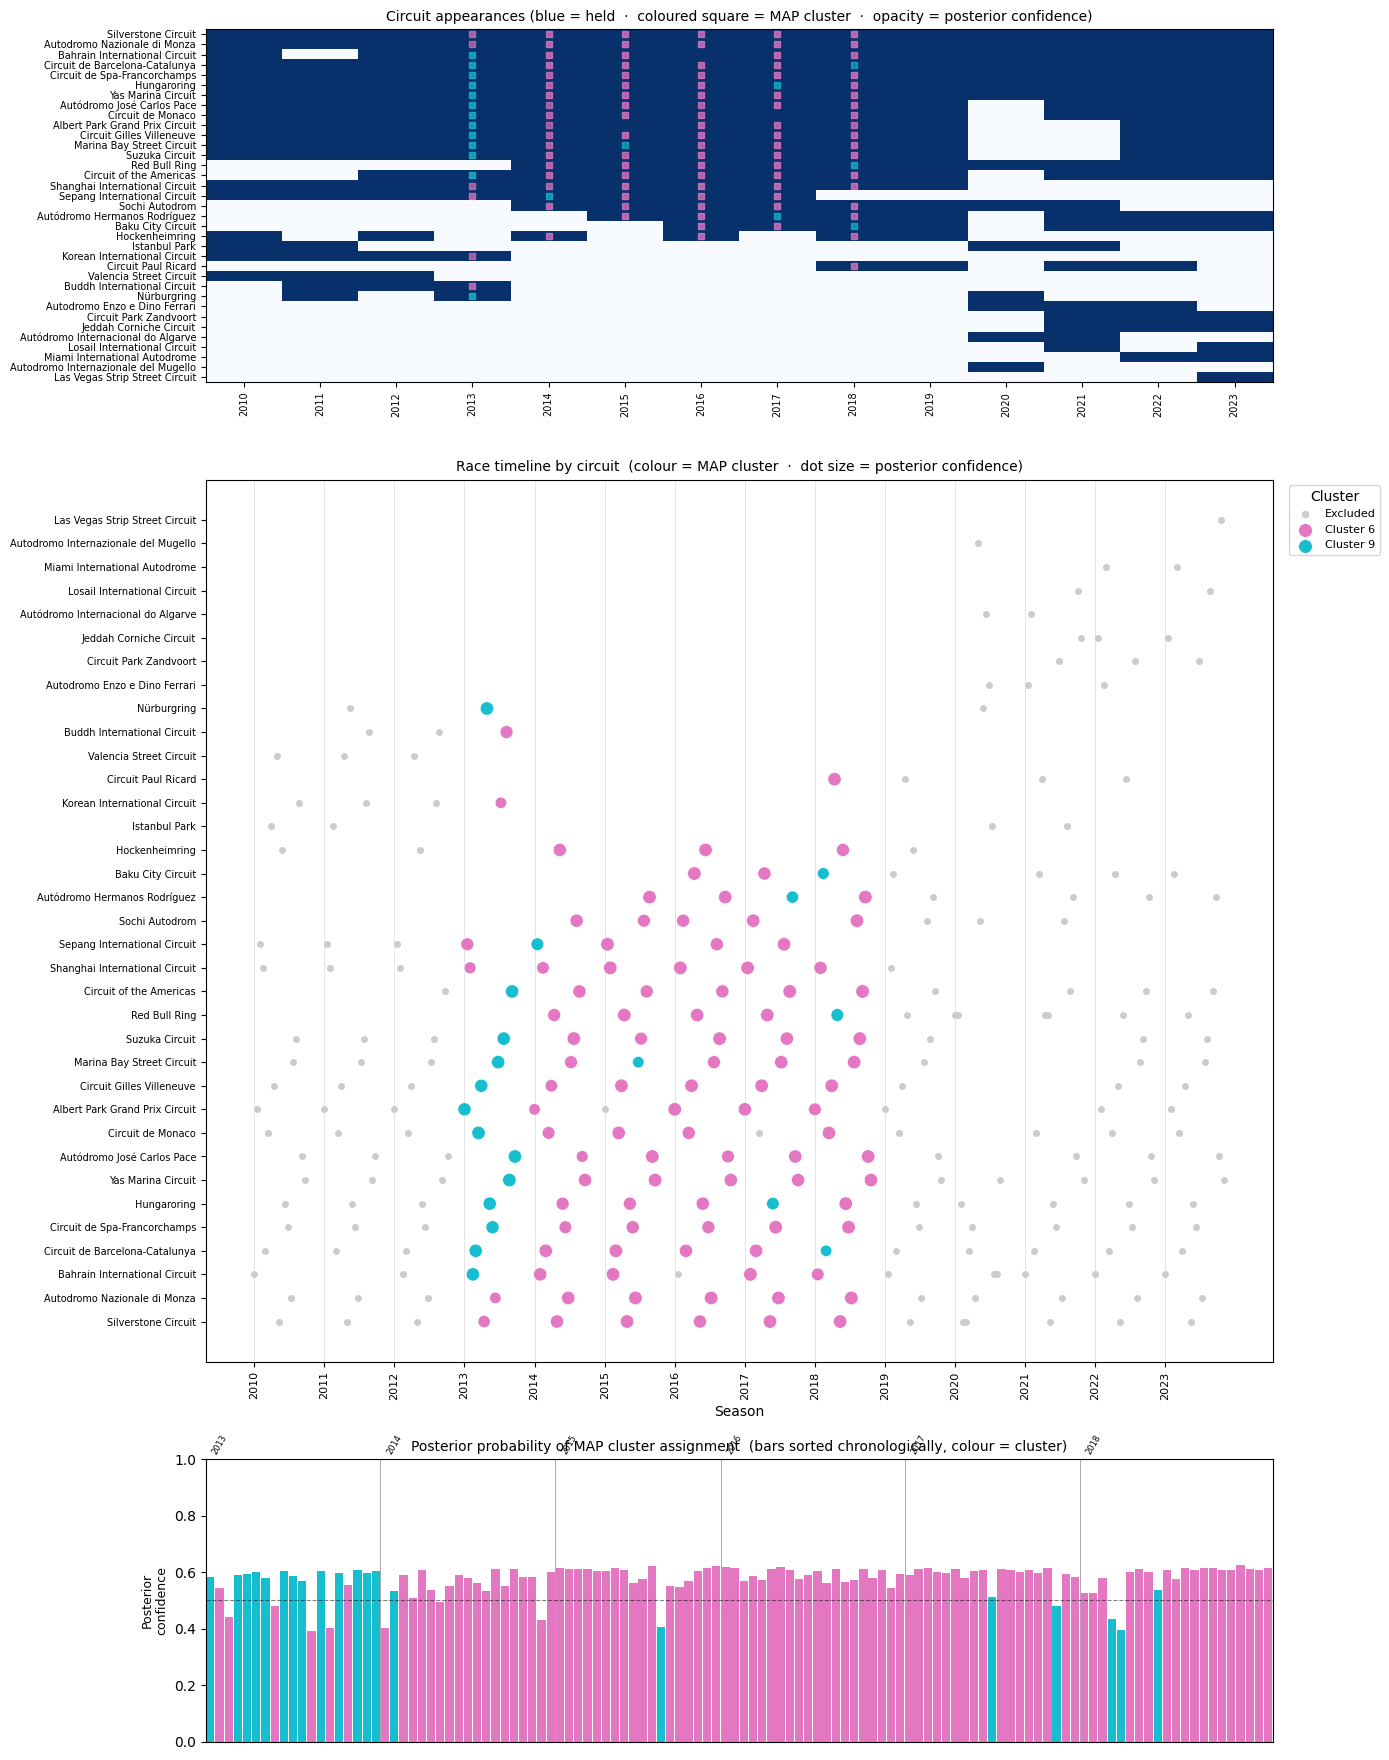

In [43]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── MAP cluster assignments and posterior confidence ──────────────────────────
z_map = map_result["z"]   # per-race MAP cluster label, length = len(races)

# Posterior probability of each race's MAP cluster (how often in that cluster)
# p_ic[i][c] = fraction of post-burn-in samples where race i was in cluster c
T = len(samples.z_samples)
N = len(races)
counts_ = [[0] * C for _ in range(N)]
for z_ in samples.z_samples:
    for i, c_ in enumerate(z_):
        counts_[i][c_] += 1
p_ic = [[counts_[i][c_] / T for c_ in range(C)] for i in range(N)]
confidence = [p_ic[i][z_map[i]] for i in range(N)]   # posterior prob of MAP label

# ── Build full race catalogue ─────────────────────────────────────────────────
all_races2 = (
    rankings[["season", "round", "race_name", "circuit"]]
    .drop_duplicates()
    .copy()
)
all_races2["race_label"] = (
    all_races2["season"].astype(str)
    + " R" + all_races2["round"].astype(str).str.zfill(2)
    + " " + all_races2["race_name"]
)

subset_map_df = pd.DataFrame({
    "race_label":  races,
    "cluster":     z_map,
    "confidence":  confidence,
})
all_races2 = all_races2.merge(subset_map_df, on="race_label", how="left")
all_races2["in_subset"] = all_races2["cluster"].notna()

# ── Sort circuits by frequency then first appearance ─────────────────────────
circuit_order2 = (
    all_races2.groupby("circuit")
    .agg(total=("season", "count"), first=("season", "min"))
    .sort_values(["total", "first"], ascending=[False, True])
    .index.tolist()
)
all_races2["circuit_rank"] = all_races2["circuit"].map(
    {c: i for i, c in enumerate(circuit_order2)}
)

n_circuits2 = len(circuit_order2)
seasons2    = sorted(all_races2["season"].unique())
cmap_cl2    = plt.get_cmap("tab10")

fig, axes = plt.subplots(
    3, 1,
    figsize=(max(14, len(seasons2) * 0.65), 10 + n_circuits2 * 0.22),
    gridspec_kw={"height_ratios": [1, 2.5, 0.8]},
)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 1 — Circuit × Season heatmap  (MAP cluster coloured squares)
# ═══════════════════════════════════════════════════════════════════════════════
ax1 = axes[0]

presence2 = (
    all_races2.groupby(["circuit", "season"])
    .size()
    .unstack(fill_value=0)
    .gt(0)
    .astype(float)
    .reindex(index=circuit_order2, columns=seasons2, fill_value=0)
)
ax1.imshow(presence2.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)

for _, row in all_races2[all_races2["in_subset"]].iterrows():
    ci2 = circuit_order2.index(row["circuit"])
    si2 = seasons2.index(row["season"])
    cl2 = int(row["cluster"])
    ax1.plot(si2, ci2, "s", color=cmap_cl2(cl2 % 10),
             markersize=5, zorder=3, alpha=float(row["confidence"]) * 0.6 + 0.4)

ax1.set_xticks(range(len(seasons2)))
ax1.set_xticklabels(seasons2, rotation=90, fontsize=7)
ax1.set_yticks(range(n_circuits2))
ax1.set_yticklabels(circuit_order2, fontsize=7)
ax1.set_title(
    "Circuit appearances (blue = held  ·  coloured square = MAP cluster  ·  opacity = posterior confidence)",
    fontsize=10,
)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 2 — Timeline scatter (MAP cluster, dot size ∝ confidence)
# ═══════════════════════════════════════════════════════════════════════════════
ax2 = axes[1]

excl2 = all_races2[~all_races2["in_subset"]]
ax2.scatter(
    excl2["season"] + (excl2["round"] - 1) / 25,
    excl2["circuit_rank"],
    color="#cccccc", s=16, zorder=2, label="Excluded",
)

incl2 = all_races2[all_races2["in_subset"]].copy()
incl2["cluster"] = incl2["cluster"].astype(int)
for cl2 in sorted(incl2["cluster"].unique()):
    m2 = incl2["cluster"] == cl2
    sz = incl2.loc[m2, "confidence"] * 120 + 20   # size 20..140
    ax2.scatter(
        incl2.loc[m2, "season"] + (incl2.loc[m2, "round"] - 1) / 25,
        incl2.loc[m2, "circuit_rank"],
        color=cmap_cl2(cl2 % 10), s=sz, zorder=3, label=f"Cluster {cl2}",
        edgecolors="white", linewidths=0.4,
    )

ax2.set_yticks(range(n_circuits2))
ax2.set_yticklabels(circuit_order2, fontsize=7)
ax2.set_xticks(seasons2)
ax2.set_xticklabels(seasons2, rotation=90, fontsize=8)
ax2.set_xlabel("Season", fontsize=10)
ax2.set_title(
    "Race timeline by circuit  (colour = MAP cluster  ·  dot size = posterior confidence)",
    fontsize=10,
)
ax2.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Cluster", markerscale=1.1)
for s2 in seasons2:
    ax2.axvline(s2, color="#e0e0e0", linewidth=0.6, zorder=1)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 3 — Posterior confidence per race (sorted by season/round)
# ═══════════════════════════════════════════════════════════════════════════════
ax3 = axes[2]

conf_df = (
    subset_map_df
    .merge(
        rankings[["season", "round", "race_name", "circuit"]]
        .assign(race_label=lambda d:
            d["season"].astype(str) + " R" + d["round"].astype(str).str.zfill(2)
            + " " + d["race_name"]
        )
        .drop_duplicates("race_label"),
        on="race_label",
    )
    .sort_values(["season", "round"])
    .reset_index(drop=True)
)

bar_colors = [cmap_cl2(int(c2) % 10) for c2 in conf_df["cluster"]]
ax3.bar(range(len(conf_df)), conf_df["confidence"], color=bar_colors, width=0.9)
ax3.axhline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax3.set_xlim(-0.5, len(conf_df) - 0.5)
ax3.set_ylim(0, 1)
ax3.set_ylabel("Posterior\nconfidence", fontsize=9)
ax3.set_xticks([])
ax3.set_title(
    "Posterior probability of MAP cluster assignment  (bars sorted chronologically, colour = cluster)",
    fontsize=10,
)
# Season boundary markers
season_starts = conf_df.groupby("season").apply(lambda g: g.index[0]).to_dict()
for ssn, idx in season_starts.items():
    ax3.axvline(idx - 0.5, color="#aaaaaa", linewidth=0.7, zorder=1)
    ax3.text(idx, 1.01, str(ssn), fontsize=6, ha="left", va="bottom",
             transform=ax3.get_xaxis_transform(), rotation=60)

plt.tight_layout()
plt.show()
